In [10]:
import os
from dotenv import load_dotenv
from typing import TypedDict, Literal
from typing_extensions import Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


In [3]:
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

llm = ChatOpenAI(model="gpt-4o-mini", api_key=api_key, temperature=0.7, streaming=True)


In [14]:
# -----------------------------
# Graph State
# -----------------------------
class State(TypedDict):
    user_query: str
    appointment_type: str
    empathetic_reply: str
    appointment_options: str
    user_confirmation: str
    final_status: str

# ---------------------

In [5]:
# -----------------------------
# Structured Output for Routing
# -----------------------------
class Intent(BaseModel):
    appointment_type: Literal["doctor", "finance"]
    needs_confirmation: bool

extract_intent = llm.with_structured_output(Intent, method="json_schema", strict=True)


In [6]:
# -----------------------------
# Nodes
# -----------------------------

def empathize_node(state: State):
    reply = llm.invoke(
        f"Respond empathetically to this user's problem and ask one gentle follow-up question: {state['user_query']}"
    )
    return {"empathetic_reply": reply.content}


def classify_intent_node(state: State):
    result = extract_intent.invoke(state["user_query"])
    return {
        "appointment_type": result.appointment_type,
        "user_confirmation": "pending" if result.needs_confirmation else "skip",
    }


def suggest_appointment_node(state: State):
    suggestion = llm.invoke(
        f"Suggest 3 time slots for a {state['appointment_type']} appointment in a warm and caring tone."
    )
    return {"appointment_options": suggestion.content}


def human_confirmation_node(state: State):
    return {
        "empathetic_reply": "Please confirm: Should I book this appointment? (yes/no)",
        "user_confirmation": "awaiting_user",
    }


def finalize_node(state: State):
    if state.get("user_confirmation") == "yes":
        return {"final_status": "Appointment booked successfully!"}
    else:
        return {"final_status": "Okay, I won't book it right now. Let me know if you need anything else."}


In [7]:
# -----------------------------
# Routing
# -----------------------------

def route_after_intent(state: State):
    if state["user_confirmation"] == "pending":
        return "NeedHuman"
    return "Suggest"


In [8]:
# -----------------------------
# Build Graph
# -----------------------------

builder = StateGraph(State)

builder.add_node("Empathize", empathize_node)
builder.add_node("Classify", classify_intent_node)
builder.add_node("Suggest", suggest_appointment_node)
builder.add_node("NeedHuman", human_confirmation_node)
builder.add_node("Finalize", finalize_node)

builder.add_edge(START, "Empathize")
builder.add_edge("Empathize", "Classify")

builder.add_conditional_edges(
    "Classify", route_after_intent, {"NeedHuman": "NeedHuman", "Suggest": "Suggest"}
)

builder.add_edge("NeedHuman", END)  # human must reply manually
builder.add_edge("Suggest", "Finalize")
builder.add_edge("Finalize", END)

workflow = builder.compile()


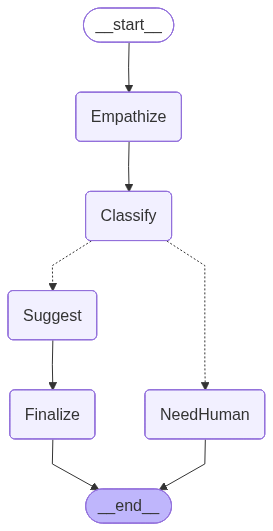

In [11]:
# Visualize
display(Image(workflow.get_graph().draw_mermaid_png()))

# Run workflow

In [16]:
# Run workflow
state = workflow.invoke({"user_query": "I feel sick and need a doctor"})
from pprint import pprint
pprint(state)


{'appointment_type': 'doctor',
 'empathetic_reply': 'Please confirm: Should I book this appointment? (yes/no)',
 'user_confirmation': 'awaiting_user',
 'user_query': 'I feel sick and need a doctor'}


In [18]:
# Run workflow
state = workflow.invoke({"user_query": "yes please book the appointment"})
from pprint import pprint
pprint(state)

{'appointment_type': 'doctor',
 'empathetic_reply': 'Please confirm: Should I book this appointment? (yes/no)',
 'user_confirmation': 'awaiting_user',
 'user_query': 'yes please book the appointment'}


In [19]:
print(state["empathetic_reply"])

Please confirm: Should I book this appointment? (yes/no)
